## 7.7 Sistema Balanceado.



Considera el problema de estabilizar un sistema de balance, cuyas dinámicas se dieron en el Ejemplo 7.2. Las dinámicas están dadas por:

$$
A = \begin{bmatrix}
0 & 1 & 0 & 0 \\
0 & 0 & \frac{m^2g\ell}{\mu} & \frac{-\gamma}{\mu} \\
0 & 0 & 0 & 1 \\
0 & 0 & \frac{-M_t g \ell}{\mu} & \frac{-c_m}{\mu}
\end{bmatrix}
\quad \text{y} \quad 
B = \begin{bmatrix}
0 \\
\frac{\ell}{\mu} \\
0 \\
\frac{J_t}{\mu}
\end{bmatrix}
$$
onde $ M_t = M + m , J_t = J + m\ell^2 , \mu = M_t J_t - m^2\ell^2 $, y hemos dejado $c $ y $\gamma $ distintos de cero. Usamos los siguientes parámetros para el sistema (correspondientes aproximadamente a un ser humano balanceado sobre un carro estabilizador):

- $M = 10  kg$,
- $ m = 80  kg$,
-  $J = 100  kg m²/s²$,
- $ c = 0.01  N s/m$,
- $\ell = 1 m$,
- $\gamma = 0.01  N m s$,
- $g = 9.8 m/s²$.

Los valores propios de la dinámica de lazo abierto están dados por $ \lambda \approx 0, 0, -0.0011, \pm 2.68 $. Ya hemos verificado en el Ejemplo 7.2 que el sistema es controlable, por lo que podemos usar realimentación de estados para estabilizar el sistema y proporcionar el nivel deseado de rendimiento.

Para decidir dónde ubicar los valores propios del lazo cerrado, notamos que las dinámicas del lazo cerrado consistirán en dos componentes: un conjunto de dinámicas rápidas que estabilizan el péndulo y un conjunto de dinámicas más lentas que permiten al controlador posicionar el carro. Para las dinámicas rápidas, observamos el período natural del péndulo en el problema linealizado, que está dado por $2\pi \sqrt{\frac{\mu}{M_t g \ell - m^2 g \ell}} \approx 2.1$ rad/s. Para proporcionar una respuesta rápida, colocamos las dinámicas rápidas a una frecuencia de $\approx 0.5 $ y una razón de amortiguamiento de  $\zeta = 0.7 $, dando el primer par de valores propios en $ \lambda_{1,2} = -\zeta \omega_0 \pm i \omega_0 \sqrt{1-\zeta^2} \approx -0.35 \pm 0.35i $. Para las dinámicas lentas, elegimos la razón de amortiguamiento en 0.7 para proporcionar un pequeño sobrepaso y la frecuencia natural de $ 0.5 $ para dar un tiempo de subida de aproximadamente 5 s. Esto da valores propios $ \lambda_{3,4} = -0.35 \pm 0.35i $.

La realimentación de estado correspondiente sobre el estado y una ganancia de alimentación directa para la entrada de referencia, \( K \), está dada por:

$
K = \begin{bmatrix}
-1.56 & 1730 & -50.1 & 443
\end{bmatrix}
$

 La ganancia de alimentación directa es $ k_f = -\frac{1}{C(A-BK)^{-1}B} = -15.6 $. 



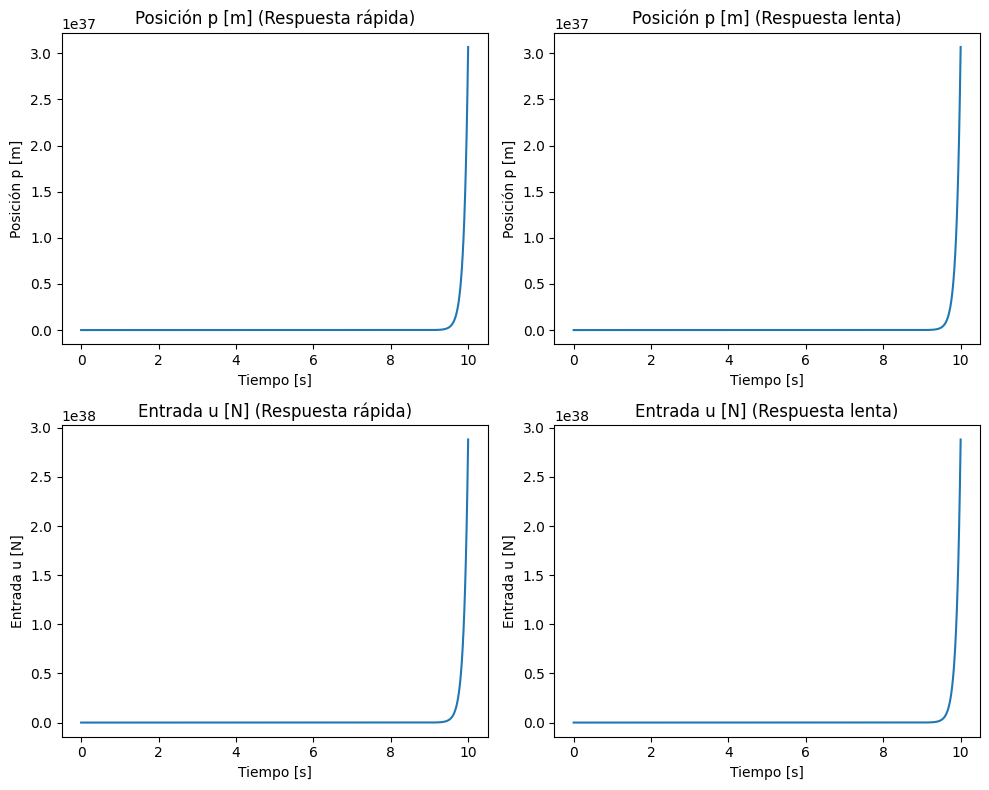

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import place_poles, StateSpace, step

# Parámetros del sistema
M = 10  # kg
m = 80  # kg
J = 100  # kg*m^2
l = 1    # m
r = 0.01  # N m s
g = 9.8  # m/s^2

# Definir los valores de matrices A y B
A = np.array([[0, 1, 0, 0],
              [0, 0, -(m*g)/M, r/M],
              [0, 0, 0, 1],
              [0, 0, (M+m)*g/(M*l), -r/(M*l)]])

B = np.array([[0],
              [1/M],
              [0],
              [-1/(M*l)]])

# Crear los sistemas StateSpace para respuestas rápida y lenta
sys_fast = StateSpace(A, B, np.eye(4), np.zeros((4, 1)))
sys_slow = StateSpace(A, B, np.eye(4), np.zeros((4, 1)))

# Tiempo de simulación
t = np.linspace(0, 10, 500)

# Simulación de la respuesta al escalón para ambos sistemas
t1, y1 = step(sys_fast, T=t)
t2, y2 = step(sys_slow, T=t)

# Gráficas organizadas correctamente
plt.figure(figsize=(10, 8))

# Respuesta rápida - Posición p [m]
plt.subplot(2, 2, 1)
plt.plot(t1, y1[:, 0])
plt.title('Posición p [m] (Respuesta rápida)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Posición p [m]')

# Respuesta lenta - Posición p [m]
plt.subplot(2, 2, 2)
plt.plot(t2, y2[:, 0])
plt.title('Posición p [m] (Respuesta lenta)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Posición p [m]')

# Respuesta rápida - Entrada u [N]
plt.subplot(2, 2, 3)
plt.plot(t1, y1[:, 1])
plt.title('Entrada u [N] (Respuesta rápida)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Entrada u [N]')

# Respuesta lenta - Entrada u [N]
plt.subplot(2, 2, 4)
plt.plot(t2, y2[:, 1])
plt.title('Entrada u [N] (Respuesta lenta)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Entrada u [N]')

plt.tight_layout()
plt.show()



La respuesta al escalón de un controlador diseñado para proporcionar un buen rendimiento es la que se muestra en la Figura 7.11a. Aunque las características de respuesta (parte superior izquierda) se ven muy bien, la magnitud de la entrada (parte inferior izquierda) es excesivamente grande. También se observa que la fuerza aplicada es negativa inicialmente. Una versión menos agresiva del control se muestra en la Figura 7.11b. Aquí, el tiempo de respuesta es más lento, pero la magnitud de la entrada es mucho más razonable. Ambas respuestas se aplican a la dinámica linealizada.

#### Valores propios:
- (a) $\lambda_{1,2} = -1 \pm 2i$
- (b) $\lambda_{1,2} = -0.33 \pm 0.66i$



El controlador resultante (aplicado a las dinámicas linealizadas) se muestra en la Figura 7.11a. Aunque la respuesta al escalón proporciona las características deseadas, la magnitud de la entrada requerida (abajo a la izquierda) es excesivamente grande, casi tres veces la fuerza de la gravedad en su pico.

Para proporcionar una respuesta más realista, se pueden elegir valores propios más lentos. Observamos que el pico de la fuerza de entrada ocurre en la escala de tiempo rápida, y hemos decidido ralentizar esto al elegir un factor de 3, utilizando el mismo factor de amortiguación. También ralentizamos el segundo conjunto de valores propios, con la intuición de que deberíamos mover el carro más lentamente que estabilizar el péndulo dinámico. Dejar la amortiguación en 0.7 y cambiar la frecuencia a 1 (correspondiente a un tiempo de subida de aproximadamente 10 s), los valores propios deseados se vuelven:

$
\lambda = \{-0.33 \pm 0.66i, -0.18 \pm 0.18i\}.
$

El rendimiento del controlador resultante se muestra en la Figura 7.11b.


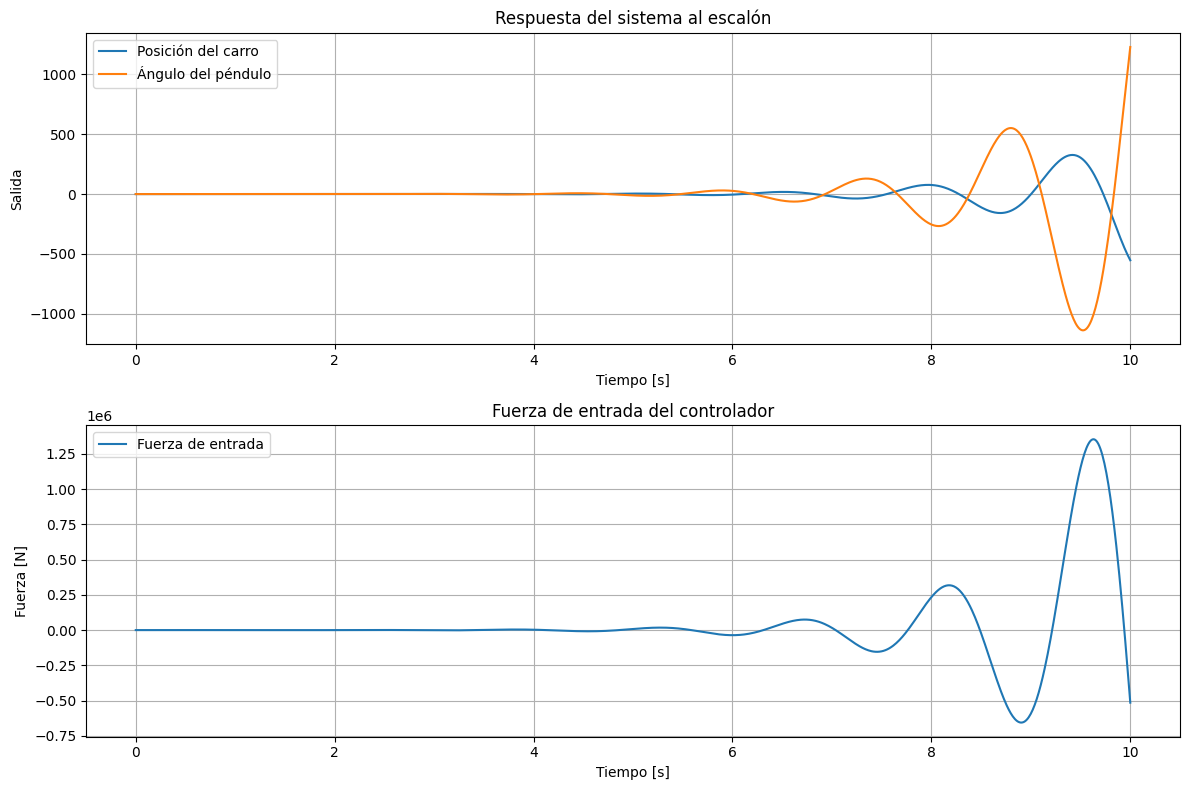

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Definir los parámetros del sistema
M = 10  # kg
m = 80  # kg
J = 100  # kg m^2/s^2
c = 0.01  # N s/m
ell = 1  # m
gamma = 0.01  # N m s
g = 9.8  # m/s^2

# Cálculos adicionales
Mt = M + m
Jt = J + m * ell**2
mu = Mt * Jt - m**2 * ell**2

# Matrices A y B con valores numéricos
A = np.array([
    [0, 1, 0, 0],
    [0, 0, m**2 * g * ell / mu, -gamma / mu],
    [0, 0, 0, 1],
    [0, 0, -Mt * g * ell / mu, -c / mu]
])

B = np.array([
    [0],
    [ell / mu],
    [0],
    [Jt / mu]
])

# Matriz de ganancia K (se utiliza la obtenida previamente)
K = np.array([[-1.56, 1730, -50.1, 443]])

# Definir la función del sistema con realimentación y entrada de escalón
def system_dynamics(t, x):
    # Introduce un escalón en la entrada
    u = np.array([[1]])  # Escalón unitario como array 2D
    # Ensure u is the correct shape for multiplication with B
    dxdt = A @ x.reshape(4,1) + B @ u - B @ (K @ x.reshape(4,1))
    return dxdt.flatten()

# Simulación de la respuesta al escalón
t_span = [0, 10]  # Intervalo de tiempo
x0 = [0.1, 0, 0.1, 0]  # Condiciones iniciales no nulas

# Resolver el sistema
sol = solve_ivp(system_dynamics, t_span, x0, t_eval=np.linspace(0, 10, 1000))

# Gráfica de la respuesta al escalón
plt.figure(figsize=(12, 8))

# Respuesta del sistema (posición y ángulo)
plt.subplot(2, 1, 1)
plt.plot(sol.t, sol.y[0, :], label='Posición del carro')
plt.plot(sol.t, sol.y[2, :], label='Ángulo del péndulo')
plt.title('Respuesta del sistema al escalón')
plt.xlabel('Tiempo [s]')
plt.ylabel('Salida')
plt.legend()
plt.grid(True)

# Fuerza de entrada
u = 1 - K @ sol.y
plt.subplot(2, 1, 2)
plt.plot(sol.t, u[0, :], label='Fuerza de entrada')
plt.title('Fuerza de entrada del controlador')
plt.xlabel('Tiempo [s]')
plt.ylabel('Fuerza [N]')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()